In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('yield_df.csv')
df = df.drop(columns=['Unnamed: 0'])

print("年份范围：", df['Year'].min(), "~", df['Year'].max())
print("国家数量：", df['Area'].nunique())
print("作物种类：", df['Item'].nunique())

年份范围： 1990 ~ 2013
国家数量： 101
作物种类： 10


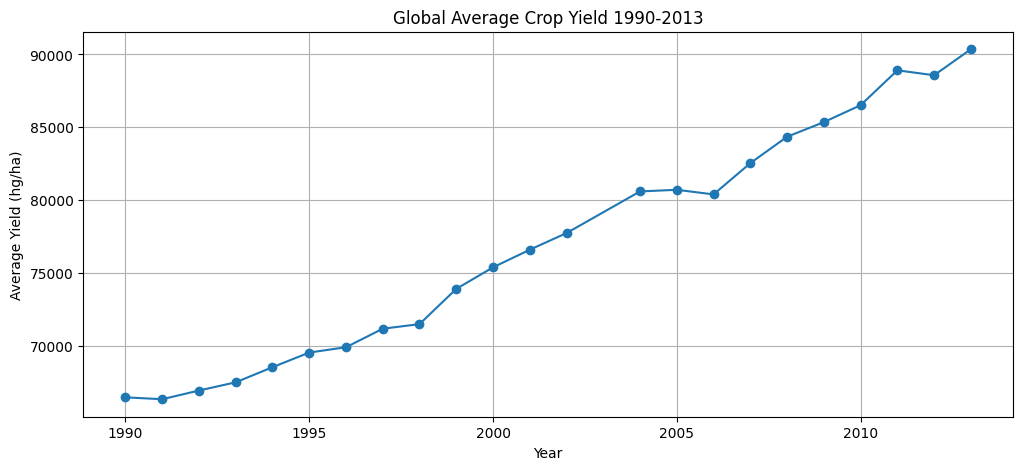

In [2]:
yearly = df.groupby('Year')['hg/ha_yield'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['hg/ha_yield'], marker='o')
plt.title('Global Average Crop Yield 1990-2013')
plt.xlabel('Year')
plt.ylabel('Average Yield (hg/ha)')
plt.grid(True)
plt.show()

In [7]:
print(df['Area'].unique())

['Albania' 'Algeria' 'Angola' 'Argentina' 'Armenia' 'Australia' 'Austria'
 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh' 'Belarus' 'Belgium'
 'Botswana' 'Brazil' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Canada' 'Central African Republic' 'Chile' 'Colombia' 'Croatia'
 'Denmark' 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'Eritrea'
 'Estonia' 'Finland' 'France' 'Germany' 'Ghana' 'Greece' 'Guatemala'
 'Guinea' 'Guyana' 'Haiti' 'Honduras' 'Hungary' 'India' 'Indonesia' 'Iraq'
 'Ireland' 'Italy' 'Jamaica' 'Japan' 'Kazakhstan' 'Kenya' 'Latvia'
 'Lebanon' 'Lesotho' 'Libya' 'Lithuania' 'Madagascar' 'Malawi' 'Malaysia'
 'Mali' 'Mauritania' 'Mauritius' 'Mexico' 'Montenegro' 'Morocco'
 'Mozambique' 'Namibia' 'Nepal' 'Netherlands' 'New Zealand' 'Nicaragua'
 'Niger' 'Norway' 'Pakistan' 'Papua New Guinea' 'Peru' 'Poland' 'Portugal'
 'Qatar' 'Romania' 'Rwanda' 'Saudi Arabia' 'Senegal' 'Slovenia'
 'South Africa' 'Spain' 'Sri Lanka' 'Sudan' 'Suriname' 'Sweden'
 'Switzerland' 'Tajikistan

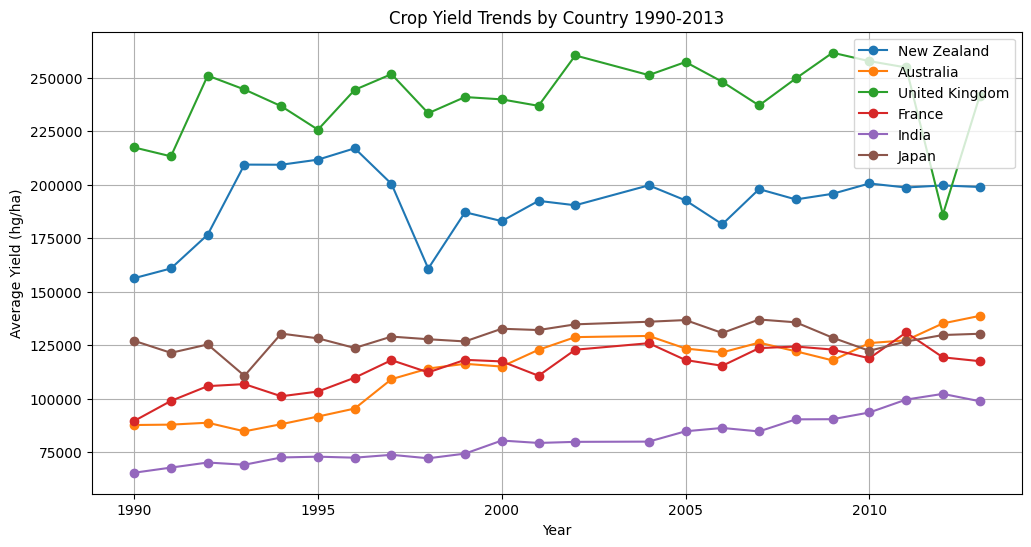

In [8]:
countries = ['New Zealand', 'Australia', 'United Kingdom', 'France', 'India', 'Japan']

plt.figure(figsize=(12, 6))

for country in countries:
    data = df[df['Area'] == country].groupby('Year')['hg/ha_yield'].mean()
    plt.plot(data.index, data.values, marker='o', label=country)

plt.title('Crop Yield Trends by Country 1990-2013')
plt.xlabel('Year')
plt.ylabel('Average Yield (hg/ha)')
plt.legend()
plt.grid(True)
plt.show()

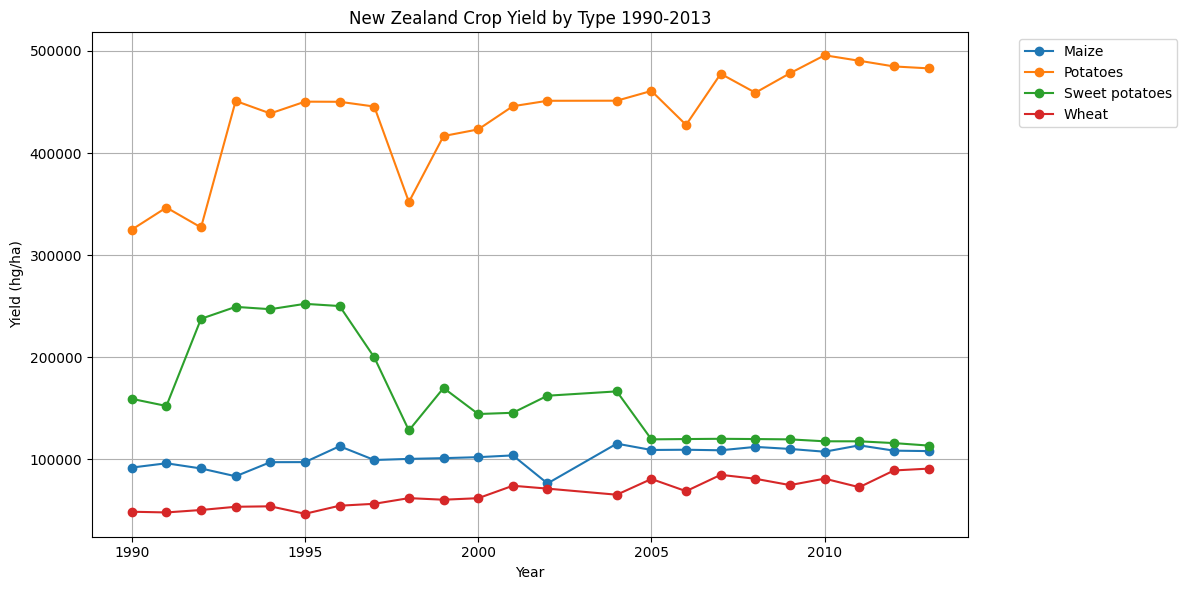

In [9]:
nz_crops = df[df['Area'] == 'New Zealand'].groupby(['Year', 'Item'])['hg/ha_yield'].mean().unstack()

plt.figure(figsize=(12, 6))
for crop in nz_crops.columns:
    plt.plot(nz_crops.index, nz_crops[crop], marker='o', label=crop)

plt.title('New Zealand Crop Yield by Type 1990-2013')
plt.xlabel('Year')
plt.ylabel('Yield (hg/ha)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

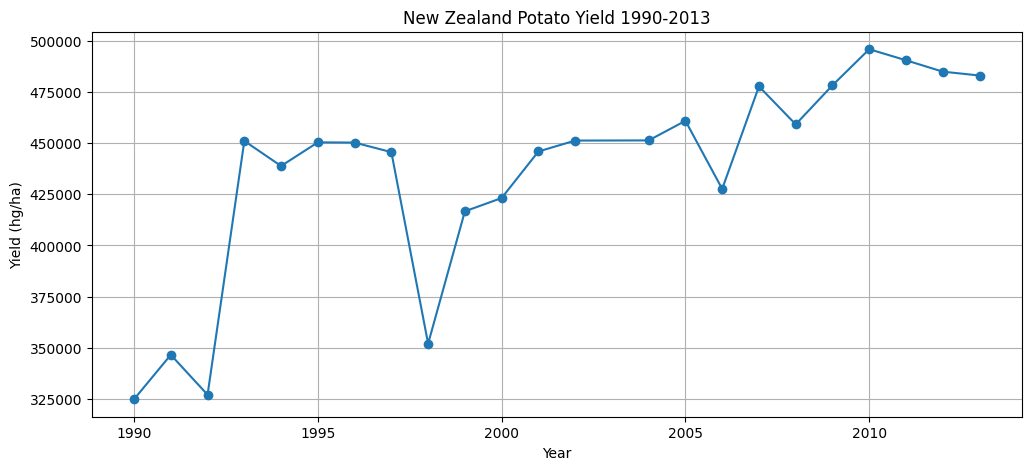

      hg/ha_yield
Year             
1990       325000
1991       346667
1992       327179
1993       451015
1994       438786
1995       450321
1996       450207
1997       445545
1998       352113
1999       416667
2000       423155
2001       445871
2002       451182
2004       451264
2005       460829
2006       427584
2007       477612
2008       459091
2009       478154
2010       495751
2011       490361
2012       484810
2013       482926


In [10]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

nz_potato = df[(df['Area'] == 'New Zealand') & (df['Item'] == 'Potatoes')][['Year', 'hg/ha_yield']]
nz_potato = nz_potato.set_index('Year')

plt.figure(figsize=(12, 5))
plt.plot(nz_potato.index, nz_potato['hg/ha_yield'], marker='o')
plt.title('New Zealand Potato Yield 1990-2013')
plt.xlabel('Year')
plt.ylabel('Yield (hg/ha)')
plt.grid(True)
plt.show()

print(nz_potato)

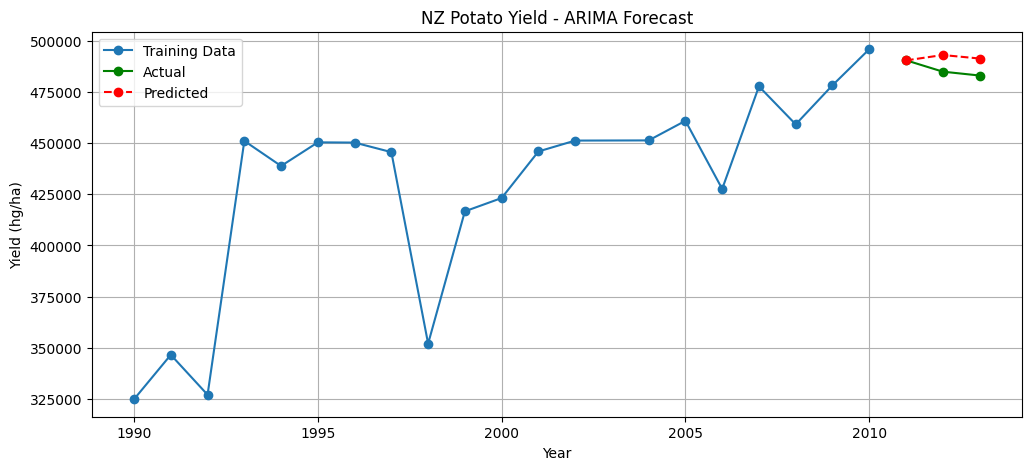


Actual vs Predicted:
2011: Actual=490361, Predicted=490286, Error=0.0%
2012: Actual=484810, Predicted=492924, Error=1.7%
2013: Actual=482926, Predicted=491217, Error=1.7%


In [13]:
train = nz_potato[nz_potato.index <= 2010]
test = nz_potato[nz_potato.index > 2010]

model = ARIMA(train, order=(2, 1, 1))
result = model.fit()

forecast = result.forecast(steps=3)
forecast.index = [2011, 2012, 2013]

plt.figure(figsize=(12, 5))
plt.plot(train.index, train['hg/ha_yield'], marker='o', label='Training Data')
plt.plot(test.index, test['hg/ha_yield'], marker='o', label='Actual', color='green')
plt.plot(forecast.index, forecast.values, marker='o', linestyle='--', label='Predicted', color='red')
plt.title('NZ Potato Yield - ARIMA Forecast')
plt.xlabel('Year')
plt.ylabel('Yield (hg/ha)')
plt.legend()
plt.grid(True)
plt.show()

print("\nActual vs Predicted:")
for year, actual, pred in zip(test.index, test['hg/ha_yield'].values, forecast.values):
    print(f"{year}: Actual={actual:.0f}, Predicted={pred:.0f}, Error={abs(actual-pred)/actual*100:.1f}%")